In [2]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
import numpy as np
import pandas as pd

# =============================================================================
# 0. ENVIRONMENT SETUP
# =============================================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# =============================================================================
# 1. CLASS DEFINITIONS
# =============================================================================
class SyntheticMaaSDataset(Dataset):
    """Dataset class matching the exact feature processing used during training."""
    def __init__(self, csv_file):
        df = pd.read_csv(csv_file)
        
        df['Age_norm'] = (df['Age'] - df['Age'].mean()) / df['Age'].std()
        df['Income_norm'] = (df['Income'] - df['Income'].mean()) / df['Income'].std()
        
        self.z = torch.tensor(df[['Age_norm', 'Income_norm']].values, dtype=torch.float32)
        self.x = torch.tensor(df[['Time_Car', 'Cost_Car', 'Time_PT', 'Cost_PT', 'Time_MaaS', 'Cost_MaaS']].values, dtype=torch.float32)
        self.choice = torch.tensor(df['Choice'].values, dtype=torch.long)
        
        # Indicator targets (shifted to 0-indexed for CrossEntropy)
        self.ind1 = torch.tensor(df['Ind_1'].values - 1, dtype=torch.long)
        self.ind2 = torch.tensor(df['Ind_2'].values - 1, dtype=torch.long)
        self.ind3 = torch.tensor(df['Ind_3'].values - 1, dtype=torch.long)

    def __len__(self):
        return len(self.choice)

    def __getitem__(self, idx):
        return self.x[idx], self.z[idx], self.choice[idx], self.ind1[idx], self.ind2[idx], self.ind3[idx]

class BI_DNN(nn.Module):
    """The Proposed Behaviorally-Informed Deep Neural Network architecture."""
    def __init__(self, x_dim=6, z_dim=2, hidden_dim=20, ind_levels=5, num_choices=3):
        super(BI_DNN, self).__init__()
        
        self.latent_net = nn.Sequential(
            nn.Linear(z_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1) 
        )
        
        self.ind1_net = nn.Linear(1, ind_levels)
        self.ind2_net = nn.Linear(1, ind_levels)
        self.ind3_net = nn.Linear(1, ind_levels)
        
        self.choice_net = nn.Sequential(
            nn.Linear(x_dim + 1, hidden_dim), 
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, num_choices)
        )

    def forward(self, x, z):
        lv = self.latent_net(z)
        ind1_logits = self.ind1_net(lv)
        ind2_logits = self.ind2_net(lv)
        ind3_logits = self.ind3_net(lv)
        
        choice_input = torch.cat((x, lv), dim=1) 
        choice_logits = self.choice_net(choice_input)
        
        return choice_logits, ind1_logits, ind2_logits, ind3_logits, lv
        
class F_DNN(nn.Module):
    def __init__(self, x_dim=6, z_dim=2, hidden_dim=20, num_choices=3):
        super(F_DNN, self).__init__()
        
        # 没有潜变量层！X 和 Z 直接拼接，暴风吸入
        self.mlp = nn.Sequential(
            nn.Linear(x_dim + z_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, num_choices)
        )

    def forward(self, x, z):
        combined_input = torch.cat((x, z), dim=1) 
        choice_logits = self.mlp(combined_input)
        return choice_logits

# =============================================================================
# 2. RECONSTRUCT EXACT TEST SPLIT
# =============================================================================
csv_file = 'synthetic_maas_dataset.csv'
original_df = pd.read_csv(csv_file)
dataset = SyntheticMaaSDataset(csv_file) 

# CRITICAL: Fix the random seed to perfectly match the training phase split
dataset_size = len(dataset)
indices = list(range(dataset_size))
np.random.seed(42)  
np.random.shuffle(indices) 
split = int(np.floor(0.2 * dataset_size))
train_indices, test_indices = indices[split:], indices[:split]

test_dataset = Subset(dataset, test_indices)
# shuffle=False ensures alignment with original_df.iloc[test_indices]
test_loader = DataLoader(test_dataset, batch_size=200, shuffle=False) 

# =============================================================================
# 3. LOAD PRE-TRAINED OPTIMAL BI-DNN WEIGHTS
# =============================================================================
model = BI_DNN().to(device)
best_weight_path = 'bc_dnn_synthetic_best_run_overall.pth' # Retained original filename

if not os.path.exists(best_weight_path):
    raise FileNotFoundError(f"Error: Pre-trained weights not found at {best_weight_path}. Please check the path.")

model.load_state_dict(torch.load(best_weight_path, map_location=device))
print(f"Successfully loaded the optimal model weights: {best_weight_path}")

model.eval()

# =============================================================================
# 4. EXTRACT PREDICTIONS AND LATENT VARIABLES
# =============================================================================
all_preds, all_lvs, all_probs = [], [], [] 

print("Extracting Choice Probabilities and Latent Variables from the Test Set...")

with torch.no_grad():
    for batch_data in test_loader:
        # batch_data contains (x, z, choice, ind1, ind2, ind3)
        x = batch_data[0].to(device)
        z = batch_data[1].to(device)
        
        # Forward pass: lv is the 5th returned element
        choice_logits, _, _, _, lv_batch = model(x, z)
        
        predictions = torch.argmax(choice_logits, dim=1)
        probabilities = torch.softmax(choice_logits, dim=1)
        
        all_preds.extend(predictions.cpu().numpy())
        all_lvs.extend(lv_batch.cpu().squeeze().numpy())
        all_probs.extend(probabilities.cpu().numpy())

# =============================================================================
# 5. MERGE WITH ORIGINAL DATA AND EXPORT
# =============================================================================
test_df = original_df.iloc[test_indices].copy()

test_df['Predicted_Choice'] = all_preds
test_df['Predicted_LV'] = all_lvs

all_probs_np = np.array(all_probs)
test_df['Prob_Car'] = all_probs_np[:, 0]
test_df['Prob_PT'] = all_probs_np[:, 1]
test_df['Prob_MaaS'] = all_probs_np[:, 2]

output_csv = 'bcdnn_predictions_with_lv_full_mediation.csv'
test_df.to_csv(output_csv, index=False)

print(f"Extraction complete! Results merged and saved to: {output_csv}")

Using device: cuda
Successfully loaded the optimal model weights: bc_dnn_synthetic_best_run_overall.pth
Extracting Choice Probabilities and Latent Variables from the Test Set...
Extraction complete! Results merged and saved to: bcdnn_predictions_with_lv_full_mediation.csv


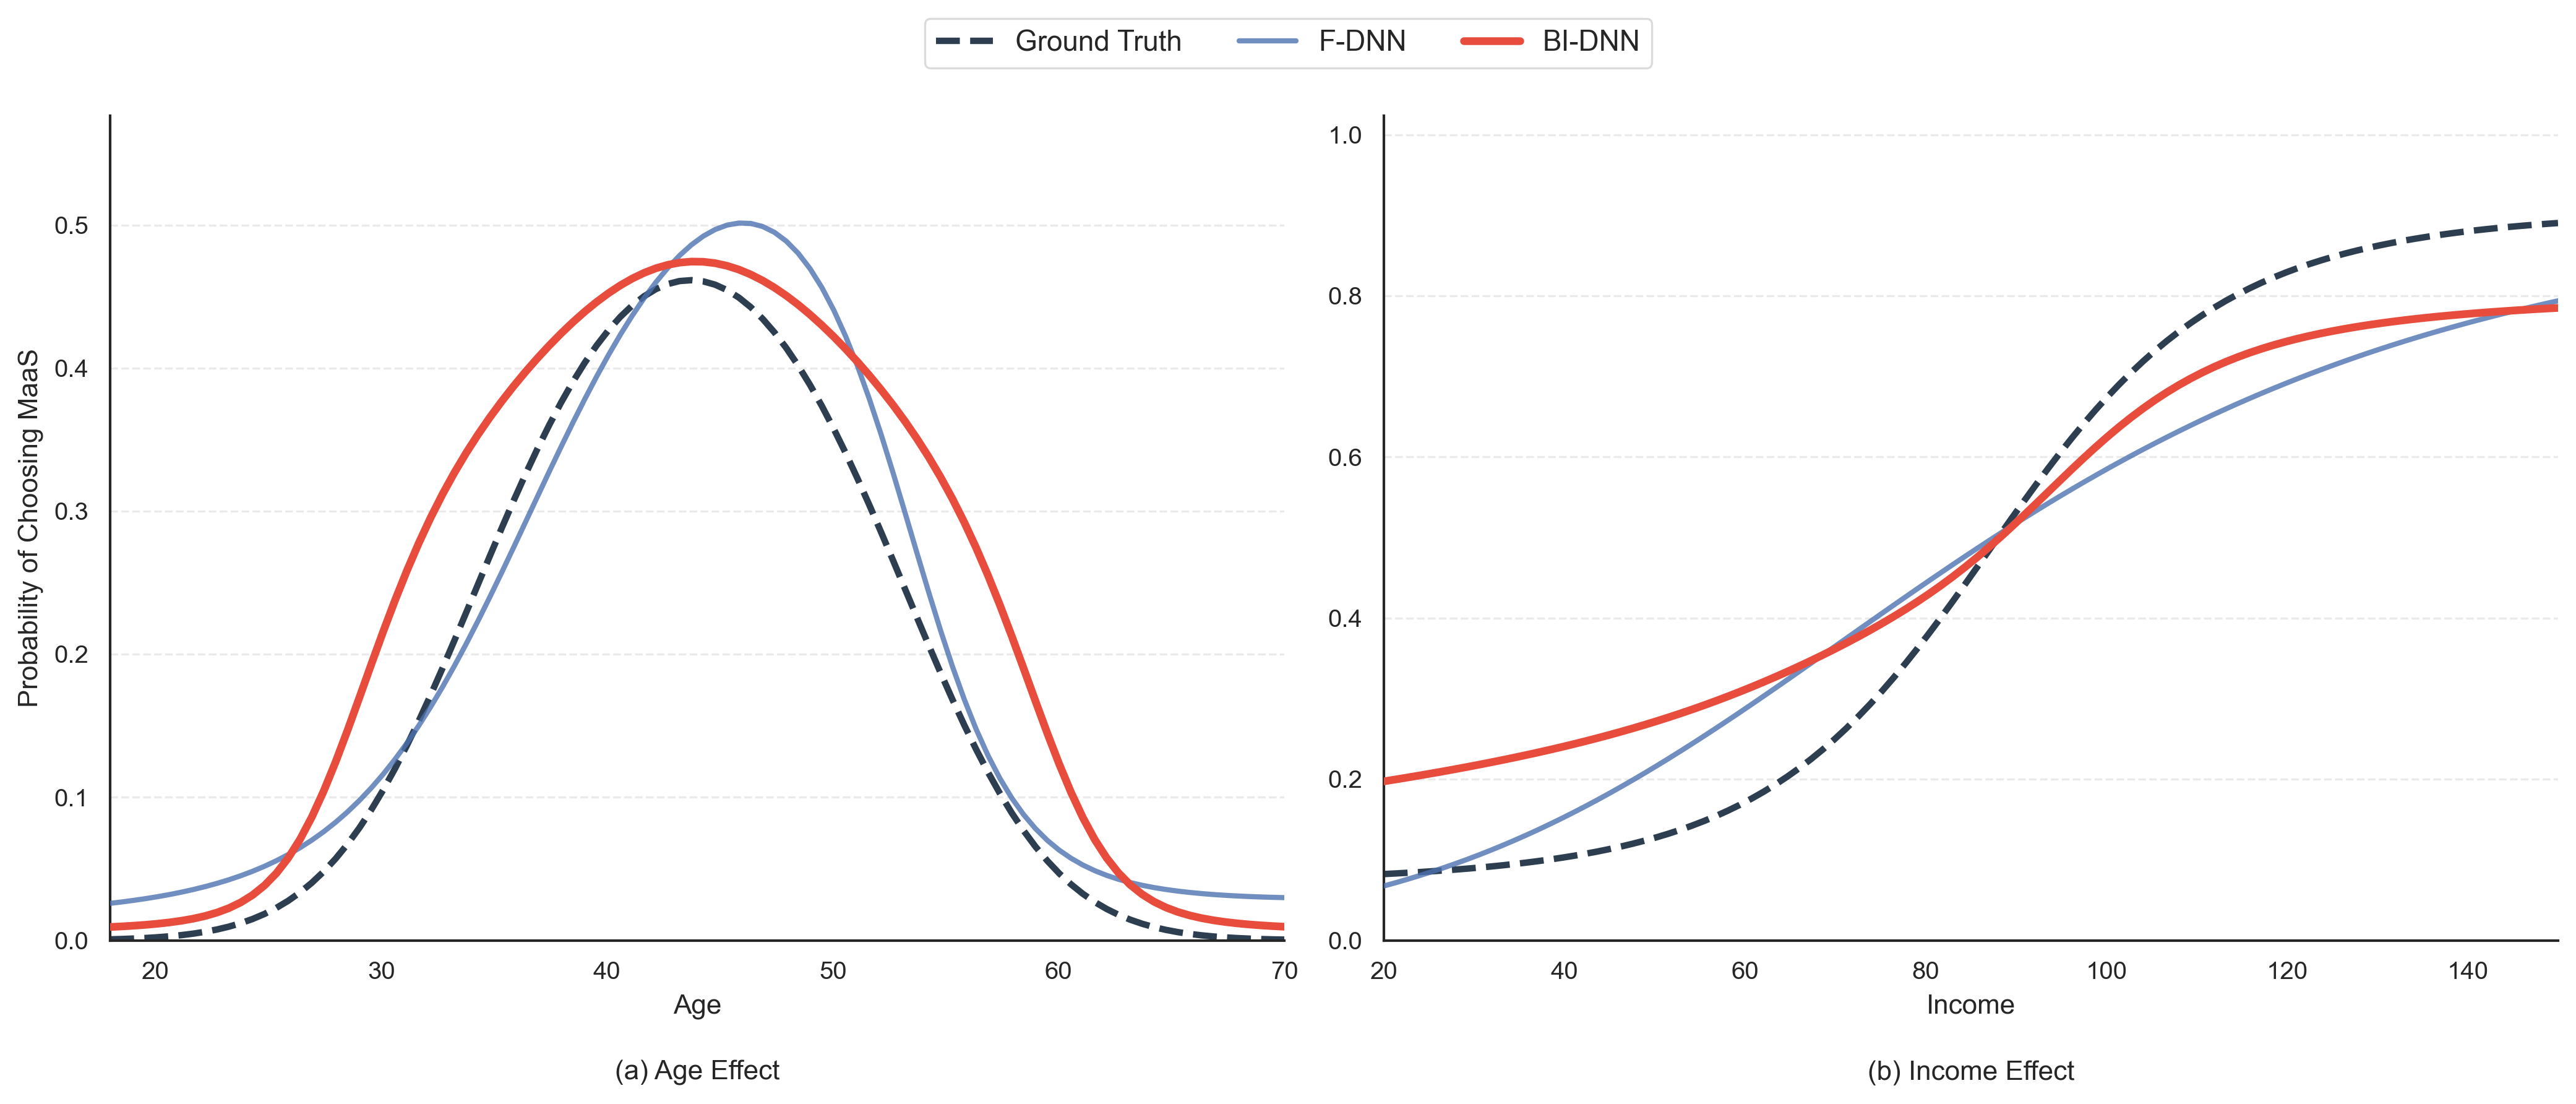

In [4]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# 1. UTILITY FUNCTIONS FOR CURVE EXTRACTION
# ==========================================
def get_prob_curve(model, model_type, feature_idx, x_mean, z_mean, f_mean, f_std, v_min, v_max):
    model.eval()
    real_vals = np.linspace(v_min, v_max, 100)
    probs_maas = []
    
    with torch.no_grad():
        for val in real_vals:
            val_norm = (val - f_mean) / f_std
            z_temp = z_mean.clone()
            z_temp[0, feature_idx] = val_norm  # feature_idx: 0=Age, 1=Income
            
            if model_type == 'fdnn':
                logits = model(x_mean, z_temp)
            elif model_type == 'bidnn':
                logits = model(x_mean, z_temp)[0] 
                
            prob = torch.softmax(logits, dim=1)[0, 2] 
            probs_maas.append(prob.item())
            
    return real_vals, np.array(probs_maas)

def get_true_dgp_prob_curve(feature_idx, x_mean_np, z_mean_np, f_mean, f_std, v_min, v_max, age_mean=None, age_std=None):
    """Calculates the theoretical Ground Truth probability based on the Data Generating Process."""
    real_vals = np.linspace(v_min, v_max, 100)
    true_probs = []
    
    ASC_Car, ASC_PT, ASC_MaaS = 0.0, -0.5, 0.5
    BETA_Time, BETA_Cost, GAMMA_LV = -0.08, -0.20, 2.0  
    
    t_car, c_car = x_mean_np[0], x_mean_np[1]
    t_pt, c_pt = x_mean_np[2], x_mean_np[3]
    t_maas, c_maas = x_mean_np[4], x_mean_np[5]
    
    for val in real_vals:
        val_norm = (val - f_mean) / f_std

        if feature_idx == 0: 
            age_n = val_norm
            inc_n = z_mean_np[1]
        else: 
            age_n = z_mean_np[0]
            inc_n = val_norm
            
        true_lv = -1.2 * (age_n ** 2) + 1.2 * np.tanh(inc_n)
        
        v_car = ASC_Car + BETA_Time * t_car + BETA_Cost * c_car
        v_pt = ASC_PT + BETA_Time * t_pt + BETA_Cost * c_pt
        v_maas = ASC_MaaS + BETA_Time * t_maas + BETA_Cost * c_maas + GAMMA_LV * true_lv
        
        exp_car, exp_pt, exp_maas = np.exp(v_car), np.exp(v_pt), np.exp(v_maas)
        true_probs.append(exp_maas / (exp_car + exp_pt + exp_maas))
        
    return real_vals, np.array(true_probs)

# ==========================================
# 2. MAIN EXECUTION AND VISUALIZATION
# ==========================================
if __name__ == "__main__":
    df_raw = pd.read_csv('synthetic_maas_dataset.csv')
    age_m, age_s = df_raw['Age'].mean(), df_raw['Age'].std()
    inc_m, inc_s = df_raw['Income'].mean(), df_raw['Income'].std()

    dataset = SyntheticMaaSDataset('synthetic_maas_dataset.csv')
    batch_data = next(iter(DataLoader(dataset, batch_size=len(dataset), shuffle=False)))
    x_mean = batch_data[0].to(device).mean(dim=0, keepdim=True)
    z_mean = batch_data[1].to(device).mean(dim=0, keepdim=True)
    x_np, z_np = x_mean.cpu().squeeze().numpy(), z_mean.cpu().squeeze().numpy()
    
    # Load pre-trained models
    fdnn = F_DNN().to(device)
    fdnn.load_state_dict(torch.load('f_dnn_synthetic_best_run_overall.pth', map_location=device))
    bidnn = BI_DNN().to(device)
    bidnn.load_state_dict(torch.load('bc_dnn_synthetic_best_run_overall.pth', map_location=device))

    # --- Extract Response Curves for Age ---
    age_x, fdnn_age = get_prob_curve(fdnn, 'fdnn', 0, x_mean, z_mean, age_m, age_s, 18, 70)
    _, bidnn_age = get_prob_curve(bidnn, 'bidnn', 0, x_mean, z_mean, age_m, age_s, 18, 70)
    _, true_age = get_true_dgp_prob_curve(0, x_np, z_np, age_m, age_s, 18, 70)

    # --- Extract Response Curves for Income ---
    inc_x, fdnn_inc = get_prob_curve(fdnn, 'fdnn', 1, x_mean, z_mean, inc_m, inc_s, 20, 150)
    _, bidnn_inc = get_prob_curve(bidnn, 'bidnn', 1, x_mean, z_mean, inc_m, inc_s, 20, 150)
    _, true_inc = get_true_dgp_prob_curve(1, x_np, z_np, inc_m, inc_s, 20, 150)

    plt.rcParams['font.sans-serif'] = ['Arial']
    sns.set_theme(style="white", context="paper", font_scale=1.1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), dpi=300)

    c_true, c_fdnn, c_bidnn = '#2C3E50', '#4C72B0', '#E74C3C'

    ax1 = axes[0]
    ax1.plot(age_x, true_age, '--', label='Ground Truth', color=c_true, linewidth=2.5, zorder=2)
    ax1.plot(age_x, fdnn_age, label='F-DNN', color=c_fdnn, linewidth=2, alpha=0.8, zorder=3)
    ax1.plot(age_x, bidnn_age, label='BI-DNN', color=c_bidnn, linewidth=3, zorder=4)
    ax1.set_title('(a) Age Effect', y=-0.2, pad=10)
    ax1.set_xlabel('Age')
    ax1.set_ylabel('Probability of Choosing MaaS')
    ax1.set_xlim(18, 70)
    ax1.set_ylim(0, max(max(true_age), max(fdnn_age), max(bidnn_age)) * 1.15)
    ax1.grid(axis='y', linestyle='--', alpha=0.4)

    ax2 = axes[1]
    ax2.plot(inc_x, true_inc, '--', label='Ground Truth', color=c_true, linewidth=2.5, zorder=2)
    ax2.plot(inc_x, fdnn_inc, label='F-DNN', color=c_fdnn, linewidth=2, alpha=0.8, zorder=3)
    ax2.plot(inc_x, bidnn_inc, label='BI-DNN', color=c_bidnn, linewidth=3, zorder=4)
    ax2.set_title('(b) Income Effect',  y=-0.2,  pad=10)
    ax2.set_xlabel('Income')

    
    ax2.set_xlim(20, 150)
    ax2.set_ylim(0, max(max(true_inc), max(fdnn_inc), max(bidnn_inc)) * 1.15)
    ax2.grid(axis='y', linestyle='--', alpha=0.4)

    handles, labels = ax1.get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.08), 
               ncol=3, frameon=True, facecolor='white', edgecolor='lightgrey', fontsize=11)

    sns.despine()
    plt.tight_layout()
    plt.savefig('combined_behavioral_response_groundtruth.png', dpi=300, bbox_inches='tight')
    plt.show()

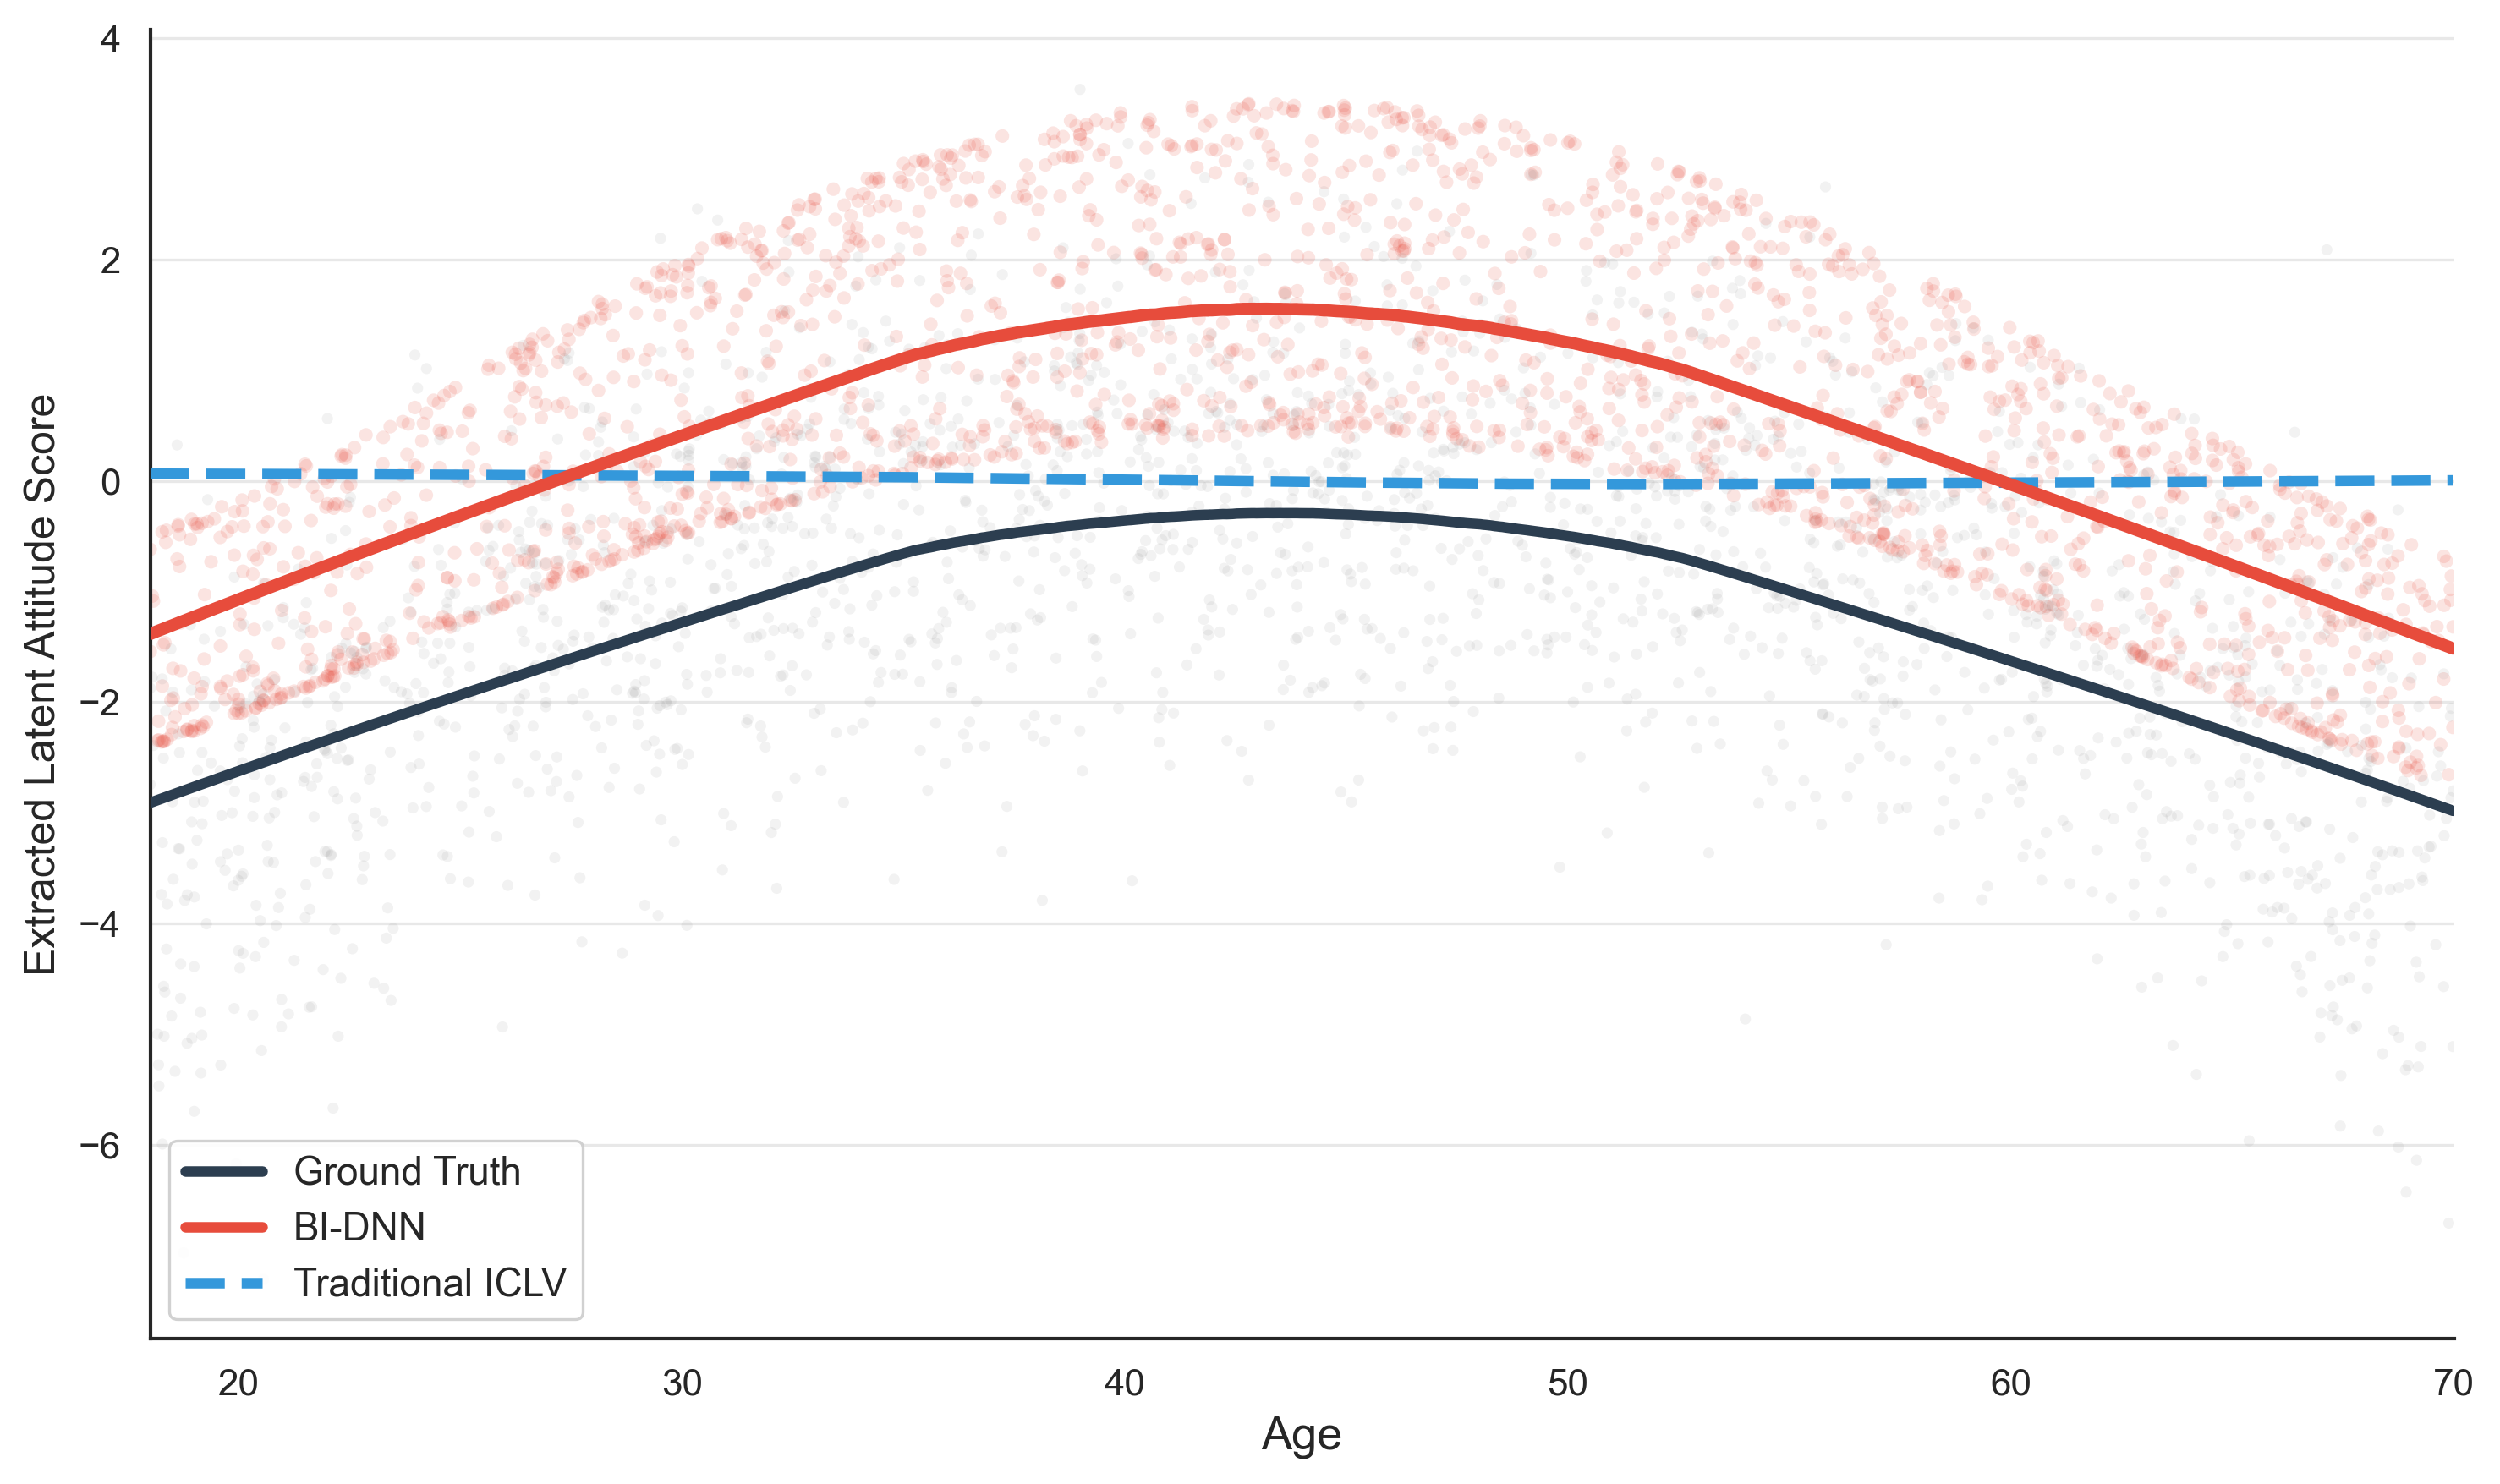

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# =============================================================================
# 1. DATA PREPARATION
# =============================================================================
df = pd.read_csv('bcdnn_predictions_with_lv_full_mediation.csv')


# --- ICLV Latent Variable Calculation ---
# Parameter estimates extracted from the traditional ICLV benchmark (Linear specification)
coef_intercept = 0.00653 
coef_age = -0.0331
coef_income = 0.534 

if 'Age_norm' not in df.columns:
    df['Age_norm'] = (df['Age'] - df['Age'].mean()) / df['Age'].std()
    df['Income_norm'] = (df['Income'] - df['Income'].mean()) / df['Income'].std()

# Reconstruct the linear ICLV latent score
df['ICLV_LV_Raw'] = coef_intercept + coef_age * df['Age_norm'] + coef_income * df['Income_norm']

# Extract arrays for plotting
age_vals = df['Age'].values
true_lv_vals = df['True_LV'].values
iclv_lv_vals = df['ICLV_LV_Raw'].values

# Sign alignment: Adjust Predicted_LV if a sign flip occurred during optimization
if df['True_LV'].corr(df['Predicted_LV']) < 0:
    bcdnn_lv_vals = -df['Predicted_LV'].values
else:
    bcdnn_lv_vals = df['Predicted_LV'].values


# =============================================================================
# 2. HIGH-QUALITY PLOTTING SETUP (Journal Style)
# =============================================================================
# Configuration for publishing standards (e.g., TR Part C, TBS)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
sns.set_theme(style="white", context="paper", font_scale=1.2)

fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

# Professional color palette
color_true = '#2C3E50'   # Dark Navy (Ground Truth)
color_bcdnn = '#E74C3C'  # Coral Red (BI-DNN)
color_iclv = '#3498DB'   # Steel Blue (Traditional ICLV)

# --- A. Background Scatter --

# Scatter points for BI-DNN
ax.scatter(age_vals, bcdnn_lv_vals, color=color_bcdnn, alpha=0.15, s=15, zorder=1, edgecolors='none')
# Scatter points for Ground Truth
ax.scatter(age_vals, true_lv_vals, color='gray', alpha=0.1, s=10, zorder=1, edgecolors='none')

# --- B. Trend Line Fitting ---
# 1. Ground Truth 
sns.regplot(x=age_vals, y=true_lv_vals, scatter=False, lowess=True, ax=ax,
            line_kws={'color': color_true, 'linewidth': 3, 'zorder': 3})

# 2. Traditional ICLV
sns.regplot(x=age_vals, y=iclv_lv_vals, scatter=False, lowess=True, ax=ax,
            line_kws={'color': color_iclv, 'linewidth': 3, 'linestyle': '--', 'zorder': 4})

# 3. BI-DNN 
sns.regplot(x=age_vals, y=bcdnn_lv_vals, scatter=False, lowess=True, ax=ax,
            line_kws={'color': color_bcdnn, 'linewidth': 3.5, 'zorder': 5})


# --- C. Custom Legend Construction ---
custom_lines = [
    Line2D([0], [0], color=color_true, lw=3, label='Ground Truth'),
    Line2D([0], [0], color=color_bcdnn, lw=3, label='BI-DNN'),
    Line2D([0], [0], color=color_iclv, lw=3, linestyle='--', label='Traditional ICLV')
]
ax.legend(handles=custom_lines, loc='lower left', fontsize=11, 
          frameon=True, facecolor='white', framealpha=0.9, edgecolor='#CCCCCC')


# --- D. Final Visual Refinement ---
ax.set_xlabel('Age', fontsize=13)
ax.set_ylabel('Extracted Latent Attitude Score', fontsize=12)

# Set axis limits for consistency
ax.set_xlim(18, 70) 

# Minimalist grid styling
ax.yaxis.grid(True, linestyle='-', which='major', color='lightgrey', alpha=0.5)
ax.set_axisbelow(True)

# Remove top and right spines for a clean aesthetic
sns.despine(ax=ax, top=True, right=True)

plt.tight_layout()
# Save the high-resolution output for the manuscript
plt.savefig('functional_form_recovery_results.png', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
# =============================================================================
# POINT ELASTICITY CALCULATION ENGINE
# =============================================================================
def calculate_economic_elasticities(model, csv_file='synthetic_maas_dataset.csv'):
    """
    Computes aggregated point elasticities for MaaS Time and Cost attributes 
    on the 100% full dataset using PyTorch Autograd.
    """
    model.to(device)
    model.eval() 
    
    # 1. Load the dataset
    dataset = SyntheticMaaSDataset(csv_file)

    # --- Compute Microeconomic Elasticit
    # Extract full dataset tensors for population-level economic analysis
    x_all = dataset.x.clone().detach().to(device)
    z_all = dataset.z.clone().detach().to(device)
    
    # Enable gradient tracking on the full input features (X)
    x_el = x_all.clone().detach().requires_grad_(True)
    z_el = z_all.clone().detach()
    
    c_logits_grad, _, _, _, _ = model(x_el, z_el)
    prob_maas = torch.softmax(c_logits_grad, dim=1)[:, 2]
    
    # Backpropagation to compute derivatives
    prob_maas.sum().backward()
    
    # 2.1 MaaS Time Elasticity (Index 4) over the entire population
    elas_time = (x_el.grad[:, 4] * (x_all[:, 4] / (prob_maas.detach() + 1e-9))).mean().item()
    
    # 2.2 MaaS Cost Elasticity (Index 5) over the entire population
    elas_cost = (x_el.grad[:, 5] * (x_all[:, 5] / (prob_maas.detach() + 1e-9))).mean().item()
    
    print("\n" + "="*45)
    print("=== AGGREGATED POINT ELASTICITIES (100% Data) ===")
    print("="*45)
    print(f"MaaS Time Elasticity: {elas_time:.4f}")
    print(f"MaaS Cost Elasticity: {elas_cost:.4f}")
    print("="*45 + "\n")

# =============================================================================
# MAIN EXECUTION
# =============================================================================
if __name__ == "__main__":
    model_weight_path = 'bc_dnn_synthetic_best_run_overall.pth' 
    
    if not os.path.exists(model_weight_path):
        print(f"Error: Weights file '{model_weight_path}' not found.")
    else:
        # Load the weights into the model
        model_eval = BI_DNN().to(device)
        model_eval.load_state_dict(torch.load(model_weight_path, map_location=device))
        print(f"Successfully loaded model weights from: {model_weight_path}")
        
        calculate_economic_elasticities(model_eval)

Successfully loaded model weights from: bc_dnn_synthetic_best_run_overall.pth

=== AGGREGATED POINT ELASTICITIES (100% Data) ===
MaaS Time Elasticity: -1.1325
MaaS Cost Elasticity: -1.0497



In [10]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
import pandas as pd

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =============================================================================
# POINT ELASTICITY CALCULATION ENGINE (F-DNN BENCHMARK)
# =============================================================================
def calculate_fdnn_elasticities(model, csv_file='synthetic_maas_dataset.csv'):
    """
    Computes aggregated point elasticities for MaaS Time and Cost attributes 
    on the 100% full dataset using the pure black-box F-DNN model.
    """
    model.to(device)
    model.eval() 
    
    # 1. Load the entire dataset 
    dataset = SyntheticMaaSDataset(csv_file)
    loader = DataLoader(dataset, batch_size=len(dataset), shuffle=False)
    batch_data = next(iter(loader))
    
    # Adapt to Dataset outputs (X, Z, Choice, etc.)
    x_all = batch_data[0].to(device)
    z_all = batch_data[1].to(device)

    # --- Compute Microeconomic Elasticity
    
    # Enable gradient tracking on the full input features (X)
    x_el = x_all.clone().detach().requires_grad_(True)
    z_el = z_all.clone().detach() # 
    
    # Forward pass through the F-DNN
    c_logits_grad = model(x_el, z_el)
    prob_maas = torch.softmax(c_logits_grad, dim=1)[:, 2] # Index 2 represents MaaS
    
    # Backpropagation to compute derivatives (dP / dX)
    prob_maas.sum().backward()
    
    # Formula: E = (dP / dX) * (X / P)
    # 2.1 MaaS Time Elasticity over the entire population
    elas_time = (x_el.grad[:, 4] * (x_all[:, 4] / (prob_maas.detach() + 1e-9))).mean().item()
    
    # 2.2 MaaS Cost Elasticity (Index 5) over the entire population
    elas_cost = (x_el.grad[:, 5] * (x_all[:, 5] / (prob_maas.detach() + 1e-9))).mean().item()
    
    print("\n" + "="*45)
    print("=== AGGREGATED POINT ELASTICITIES (F-DNN) ===")
    print("="*45)
    print(f"MaaS Time Elasticity: {elas_time:.4f}")
    print(f"MaaS Cost Elasticity: {elas_cost:.4f}")
    print("="*45 + "\n")

# =============================================================================
# MAIN EXECUTION
# =============================================================================
if __name__ == "__main__":
    model_weight_path = 'f_dnn_synthetic_best_run_overall.pth' 
    
    if not os.path.exists(model_weight_path):
        print(f"Error: Weights file '{model_weight_path}' not found. Please run F-DNN training first.")
    else:
        
        model_fdnn = F_DNN().to(device)
        model_fdnn.load_state_dict(torch.load(model_weight_path, map_location=device))
        print(f"Successfully loaded F-DNN model weights from: {model_weight_path}")
        
        calculate_fdnn_elasticities(model_fdnn)

Successfully loaded F-DNN model weights from: f_dnn_synthetic_best_run_overall.pth

=== AGGREGATED POINT ELASTICITIES (F-DNN) ===
MaaS Time Elasticity: -0.9615
MaaS Cost Elasticity: -0.8862



In [1]:
import os
import numpy as np
import pandas as pd
import biogeme.results as res

# =============================================================================
# BIOGEME POST-ESTIMATION ANALYSIS ENGINE
# =============================================================================
def evaluate_biogeme_model(csv_file='synthetic_maas_dataset.csv', pickle_file='ICLV_Synthetic_OrderedProbit.pickle'):
    """
    Loads saved Biogeme estimation results and computes predictive accuracy, 
    Choice-only NLL, and aggregate elasticities for fair comparison with Deep Learning models.
    """
    if not os.path.exists(csv_file):
        raise FileNotFoundError(f"Dataset '{csv_file}' not found.")
    if not os.path.exists(pickle_file):
        raise FileNotFoundError(f"Biogeme results file '{pickle_file}' not found. Please check the exact file name generated by Biogeme.")

    print(f"Loading dataset: {csv_file}")
    df = pd.read_csv(csv_file)
    
    # Ensure normalization matches the training phase exactly
    if 'Age_norm' not in df.columns:
        df['Age_norm'] = (df['Age'] - df['Age'].mean()) / df['Age'].std()
    if 'Income_norm' not in df.columns:
        df['Income_norm'] = (df['Income'] - df['Income'].mean()) / df['Income'].std()

    print(f"Loading Biogeme estimation results from: {pickle_file}")
    results = res.bioResults(pickleFile=pickle_file)
    
    # Retrieve the estimated dictionary of parameters
    betas = results.getBetaValues()

    # --- 1. Extract Normalized Variables & Attributes ---
    age_n = df['Age_norm'].values
    inc_n = df['Income_norm'].values
    t_car, c_car = df['Time_Car'].values, df['Cost_Car'].values
    t_pt, c_pt   = df['Time_PT'].values, df['Cost_PT'].values
    t_maas, c_maas = df['Time_MaaS'].values, df['Cost_MaaS'].values

    # --- 2. Compute Structural Equations & Utility Functions ---
    # Expected Latent Variable
    lv_pred = betas['coef_intercept'] + betas['coef_age'] * age_n + betas['coef_income'] * inc_n

    # Systematic Utilities
    v0 =  betas['B_TIME'] * t_car + betas['B_COST'] * c_car
    v1 = betas['ASC_PT'] + betas['B_TIME'] * t_pt + betas['B_COST'] * c_pt
    v2 = betas['ASC_MAAS'] + betas['B_TIME'] * t_maas + betas['B_COST'] * c_maas + betas['B_LV_MAAS'] * lv_pred

    # Logit Probabilities Calculation
    exp_v0 = np.exp(v0)
    exp_v1 = np.exp(v1)
    exp_v2 = np.exp(v2)
    sum_exp = exp_v0 + exp_v1 + exp_v2

    prob_0 = exp_v0 / sum_exp
    prob_1 = exp_v1 / sum_exp
    prob_2 = exp_v2 / sum_exp

    # --- 3. Compute Accuracy ---
    v_stack = np.vstack([v0, v1, v2])
    predicted_choice = np.argmax(v_stack, axis=0)
    
    actual_choice = df['Choice'].values
    accuracy = np.mean(predicted_choice == actual_choice)

    # --- 4. Compute Pure Choice NLL (Cross-Entropy Equivalent) ---
    probs_stack = np.vstack([prob_0, prob_1, prob_2])
    
    # Advanced indexing to extract the probability of the chosen alternative
    chosen_probs = probs_stack[actual_choice, np.arange(len(df))]
    
    # Add epsilon to prevent log(0) instability
    eps = 1e-9
    choice_nll = -np.mean(np.log(chosen_probs + eps))

    # --- 5. Compute Aggregate Elasticities ---
    # Disaggregate elasticity formula: beta_x * x * (1 - P(i))
    e_time_maas = betas['B_TIME'] * t_maas * (1 - prob_2)
    avg_elasticity_time = np.mean(e_time_maas)

    e_cost_maas = betas['B_COST'] * c_maas * (1 - prob_2)
    avg_elasticity_cost = np.mean(e_cost_maas)

    # --- 6. Summary Output ---
    print("\n" + "="*55)
    print("=== SUMMARY FOR MODEL COMPARISON (TRADITIONAL ICLV) ===")
    print("="*55)
    # Using a try-except block just in case the Biogeme version stores logLike differently in pickle
    try:
        joint_ll = results.data.logLike
        print(f"Biogeme Joint LL (with indicators):       {joint_ll:.2f}")
    except AttributeError:
        pass 
        
    print(f"Biogeme Choice NLL (Comparable to DNNs):  {choice_nll:.4f}")  
    print(f"Biogeme Accuracy:                         {accuracy * 100:.2f}%")
    print("-" * 55)
    print(f"Average Time Elasticity (MaaS):           {avg_elasticity_time:.4f}")
    print(f"Average Cost Elasticity (MaaS):           {avg_elasticity_cost:.4f}")
    print("="*55 + "\n")

# =============================================================================
# MAIN EXECUTION
# =============================================================================
if __name__ == "__main__":
    evaluate_biogeme_model(
        csv_file='synthetic_maas_dataset.csv', 
        pickle_file='ICLV_Synthetic_OrderedProbit.pickle' 
    )

Loading dataset: synthetic_maas_dataset.csv
Loading Biogeme estimation results from: ICLV_Synthetic_OrderedProbit.pickle

=== SUMMARY FOR MODEL COMPARISON (TRADITIONAL ICLV) ===
Biogeme Joint LL (with indicators):       -45433.54
Biogeme Choice NLL (Comparable to DNNs):  0.9051
Biogeme Accuracy:                         61.28%
-------------------------------------------------------
Average Time Elasticity (MaaS):           -2.3606
Average Cost Elasticity (MaaS):           -2.0264



C:\Users\Lenovo\AppData\Local\Temp\ipykernel_19280\1184923151.py:29: DeprecationWarning: Parameter 'pickleFile' is deprecated; use 'pickle_file=ICLV_Synthetic_OrderedProbit.pickle' instead.
  results = res.bioResults(pickleFile=pickle_file)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_19280\1184923151.py:32: DeprecationWarning: getBetaValues is deprecated; use get_beta_values instead.
  betas = results.getBetaValues()
